<a href="https://colab.research.google.com/github/JohnMaleek/ML/blob/main/Assignment_10_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exercise 1**
Fit random forest models with a range of tree numbers and evaluate the out-of-bag error (oob) for each of these models. Plot the resulting oob errors as a function of the number of trees. (2p)

Hint: set oob_score=True in BaggingClassifier to request an automatic OOB evaluation after training. Thereafter its valu will be available as an instance attribute.

# **FIRST SOLUTION **

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:865: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:871: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


n_estimators=10, OOB error=0.1240
n_estimators=50, OOB error=0.1020
n_estimators=100, OOB error=0.1060
n_estimators=200, OOB error=0.1040
n_estimators=300, OOB error=0.1060
n_estimators=500, OOB error=0.1060


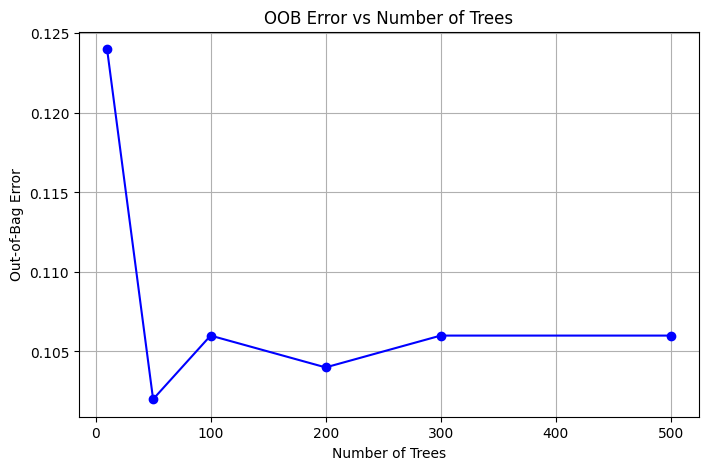

In [ ]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
import matplotlib.pyplot as plt
import numpy as np

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)

### In the first solution, the model is trained using the entire dataset:
#
#bag_clf.fit(X, y)
#This means no data is reserved for testing.

n_estimators_list = [10, 50, 100, 200, 300, 500]
oob_errors = []

for n in n_estimators_list:
    bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=n, oob_score=True, n_jobs=-1, random_state=42)
    bag_clf.fit(X, y)
    oob_errors.append(1 - bag_clf.oob_score_)
    print(f"n_estimators={n}, OOB error={oob_errors[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, oob_errors, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Trees')
plt.ylabel('Out-of-Bag Error')
plt.title('OOB Error vs Number of Trees')
plt.grid(True)
plt.show()





# **SECOND SOLUTION **

n_estimators=10, OOB error=0.1147
n_estimators=50, OOB error=0.1013
n_estimators=100, OOB error=0.1067
n_estimators=200, OOB error=0.1120
n_estimators=300, OOB error=0.1040
n_estimators=500, OOB error=0.1040


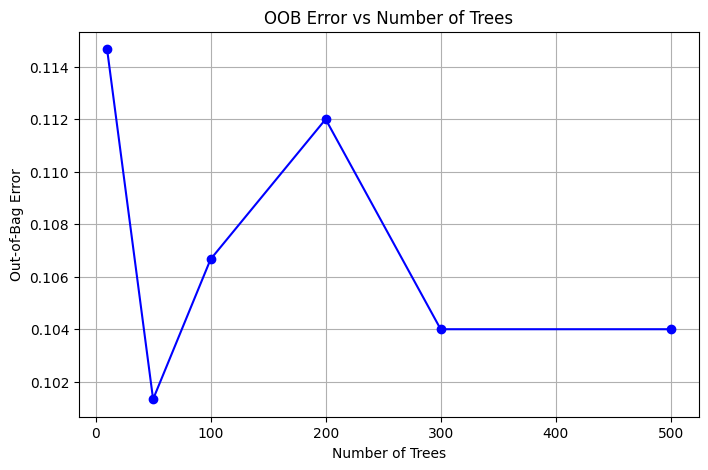

In [ ]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np


X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## In the second solution, the model is trained only on a subset of the data:

#bag_clf.fit(X_train, y_train)
#This follows a proper machine learning practice where training and testing data are separated.
#X_train, X_test, y_train, y_test
#allowing proper evaluation of the model on unseen data.

n_estimators_list = [10, 50, 100, 200, 300, 500]
oob_errors = []

for n in n_estimators_list:
    bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=n, oob_score=True, n_jobs=-1, random_state=42)
    bag_clf.fit(X_train, y_train)
    oob_errors.append(1 - bag_clf.oob_score_)
    print(f"n_estimators={n}, OOB error={oob_errors[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, oob_errors, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Trees')
plt.ylabel('Out-of-Bag Error')
plt.title('OOB Error vs Number of Trees')
plt.grid(True)
plt.show()



# **Summary**
The first solution is simpler but less reliable for evaluation since it uses all data for training.
however the second solution follows best practices by splitting the dataset, making it more suitable for machine learning tasks